In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 73623734 / 73623734 complete

Downloading bytes: 73623734 / 73623734 complete

In [2]:
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 78846023 / 78846023 complete

Downloading bytes: 78846023 / 78846023 complete

In [3]:
ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

In [4]:
pd.DataFrame(
    [
        {
            "source": label,
            "assay": type(store.RNA).__name__,
            "cells": store.cells.N,
            "active cells": int(store.cells.fetch_all("I").sum()),
            "features": store.RNA.feats.N,
        }
        for label, store in (("ctrl", ds_ctrl), ("stim", ds_stim))
    ]
)

,source,assay,cells,active cells,features
0,ctrl,RNAassay,8487,8486,35635
1,stim,RNAassay,10111,10111,35635


In [5]:
merged_path = "scarf_datasets/kang_dataset_merging.zarr"
scarf.DataStoreMerge(
    datasets=[ds_ctrl, ds_stim],
    zarr_path=merged_path,
    names=["ctrl", "stim"],
    assays=["RNA"],
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()

merged = scarf.DataStore(merged_path, nthreads=4)
merged

DataStore has 18597 (18598) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_I', 'RNA_nCounts', 
            'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo', 'orig_RNA_UMAP1', 'orig_RNA_UMAP2', 
            'orig_RNA_clusters', 'orig_RNA_leiden_cluster', 'orig_cluster_labels', 'sample_id'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

In [6]:
merged_labels = merged.cells.to_pandas_dataframe(
    ["sample_id", "orig_cluster_labels"], key="I"
)
merged_labels.groupby("sample_id")["orig_cluster_labels"].agg(
    cells="count", cell_types="nunique"
)

,cells,cell_types
sample_id,,
ctrl,8486,13
stim,10111,13


In [7]:
prepared_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)
ds = scarf.DataStore(f"{prepared_path}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
sorted(baseline)

Downloading bucket files: 99135170 / 99135170 complete

Downloading bytes: 99135170 / 99135170 complete

['analysis_cell_selection',
 'ann_index',
 'cluster_selection',
 'clusters',
 'connectivity_map',
 'embedding_initialization',
 'feature_universe',
 'highly_variable_features',
 'input_cell_selection',
 'leiden_1.0',
 'neighbors',
 'normalized',
 'pca',
 'umap']

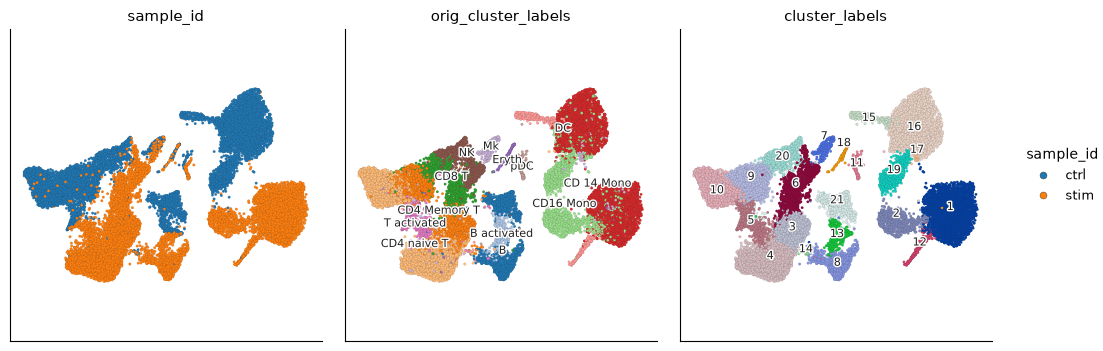

In [8]:
ds.plots.embedding(
    layout=baseline["umap"],
    color_by=["sample_id", "orig_cluster_labels", baseline["clusters"]],
    n_columns=3,
)

In [9]:
pd.crosstab(
    baseline.cells.fetch("clusters"),
    baseline.cells.fetch("sample_id"),
    rownames=["cluster"],
    colnames=["source"],
    normalize="index",
).round(3)

source,ctrl,stim
cluster,,
1,0.004,0.996
2,0.013,0.987
3,0.006,0.994
4,0.002,0.998
5,0.418,0.582
6,0.008,0.992
7,0.417,0.583
8,0.003,0.997
9,0.976,0.024
